# Notebook Tema 5 VA, Master IA UMU, curso 2025/26 (_Visión por computador utilizando CNNs_)

(Basado en notebook: _Deep Computer Vision Using Convolutional Neural Networks_ del capítulo 14 del libro de Aurelien Geron recomendado en la asignatura; éste y otros notebooks interesantes se pueden encontrar [aquí](https://github.com/ageron/handson-ml3).)



In [1]:
!date

Tue Oct 28 12:18:18 PM UTC 2025


# _Setup_

In [2]:
# Python ≥3.5 requerido
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 requerido
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version sólo existe en Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 requerido
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU detectada. CNNs serán muy lentas sin GPU.")
    if IS_COLAB:
        print("Cambiar runtime y seleccionar una GPU como acelerador hardware.")

# Import comunes:
import numpy as np
import os
import cv2

# Para hacer el notebook repetible:
np.random.seed(42)
tf.random.set_seed(42)

# Para graficar las figuras:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Dónde salvar las figuras:
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "cnn"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


Utilidades para graficar imágenes RGB y/o gris:

In [3]:
def plot_image(image):
    plt.imshow(image, cmap="gray", interpolation="nearest")
    plt.axis("off")

def plot_color_image(image):
    plt.imshow(image, interpolation="nearest")
    plt.axis("off")

# Convoluciones

Una convolución no es más que un operador lineal sencillo sobre una imagen, como cualquier filtro de los vistos en el tema 3 de la asignatura. Por ejemplo, podemos definir un par de filtros que "respondan" a bordes horizontales y verticales:

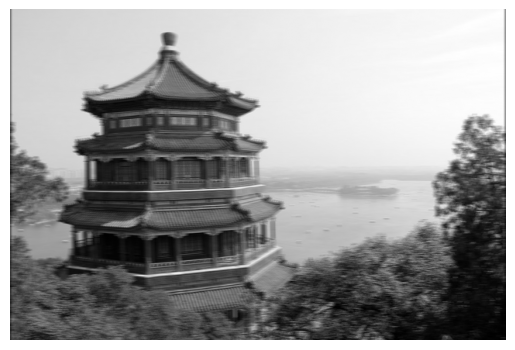

In [4]:
import numpy as np
from sklearn.datasets import load_sample_image

# Imágenes de pruba
china = load_sample_image("china.jpg") / 255
flower = load_sample_image("flower.jpg") / 255
images = np.array([china, flower])
batch_size, height, width, channels = images.shape

# Creamos 2 filtros, de tamaño 7x7 (x el número de canales):
filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1  # El primero lo inicializamos con una línea vertical en el centro de la máscara de 7x7 (columna 3)
filters[3, :, :, 1] = 1  # Y el segundo con una línea horizontal (fila 3)

# Realizamos la convolución y dibujamos, en este caso, el segundo "feature map" de la primera imagen:
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")
plt.imshow(outputs[0, :, :, 1], cmap="gray")
plt.axis("off")
plt.show()

Imprimimos los dos filtros (2), para entradas RGB (sólo el canal 0 de 3), de tamaño 7x7:

In [5]:
filters.shape
print(filters[:,:,0,0]) # Imprimimos sólo el canal R del primer filtro
print(filters[:,:,0,1]) # Ídem para el segundo filtro

[[0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


Obsérvese el tamaño del tensor de salida (en relación al tamaño de la imagen de entrada):

In [6]:
print(f'Tensor de salida: {outputs.shape} (dos imágenes, dos canales (=feature maps) de salida)')
print(f'Imágenes de entrada: {china.shape}, {flower.shape}')

Tensor de salida: (2, 427, 640, 2) (dos imágenes, dos canales (=feature maps) de salida)
Imágenes de entrada: (427, 640, 3), (427, 640, 3)


Salidas de ambos filtros para dos imágenes de ejemplo:

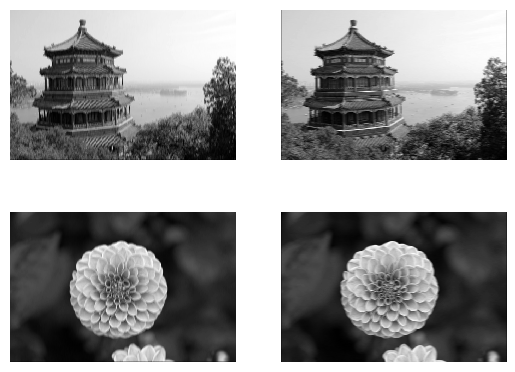

In [7]:
for image_index in (0, 1):
    for feature_map_index in (0, 1):
        plt.subplot(2, 2, image_index * 2 + feature_map_index + 1)
        plot_image(outputs[image_index, :, :, feature_map_index])

plt.show()

Imágenes ampliadas (pare ver mejor en detalle el efecto de los filtros):

In [8]:
def crop(images):
    return images[150:220, 130:250]

Saving figure china_original


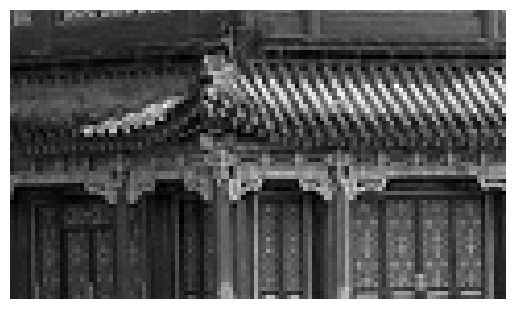

Saving figure china_vertical


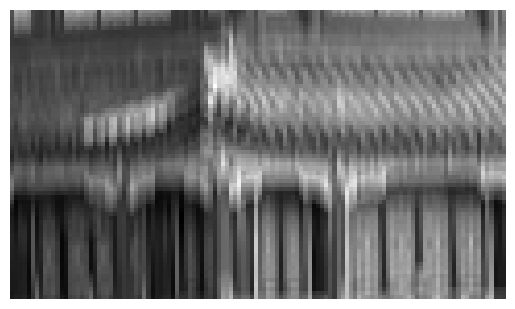

Saving figure china_horizontal


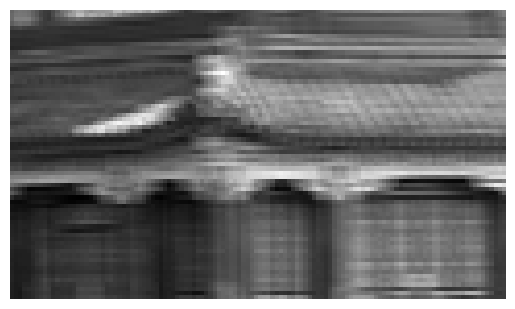

In [9]:
plot_image(crop(images[0, :, :, 0]))
save_fig("china_original", tight_layout=False)
plt.show()

for feature_map_index, filename in enumerate(["china_vertical", "china_horizontal"]):
    plot_image(crop(outputs[0, :, :, feature_map_index]))
    save_fig(filename, tight_layout=False)
    plt.show()

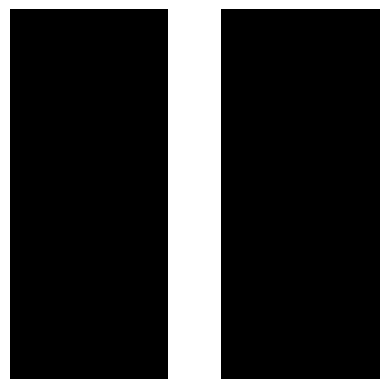

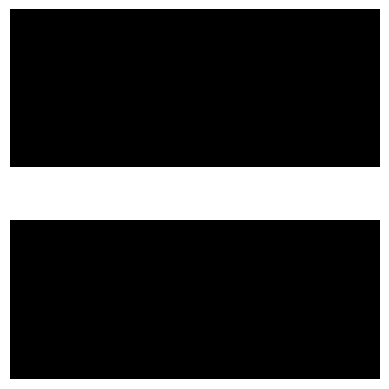

(7, 7, 3, 2)


In [10]:
plot_image(filters[:, :, 0, 0])
plt.show()
plot_image(filters[:, :, 0, 1])
plt.show()
print(filters.shape)

## Capas convolucionales

Definición usando `keras.layers.Conv2D()`:

In [11]:
conv = keras.layers.Conv2D(filters=32, kernel_size=3, strides=1,
                           padding="SAME", activation="relu")

## VALID vs SAME _padding_

Ejemplos padding "same" & "valid" con _input_width_=13, _filter_width_=6, _stride_=5:

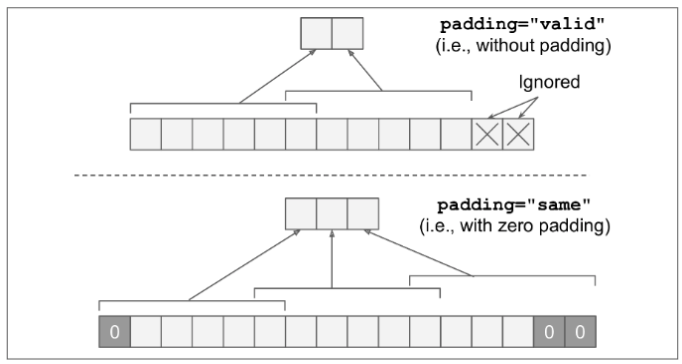

Las siguientes funciones ilustran las reglas de ambos tipos de _padding_:

In [12]:
def feature_map_size(input_size, kernel_size, strides=1, padding="SAME"):
    if padding == "SAME":
        return (input_size - 1) // strides + 1
    else:
        return (input_size - kernel_size) // strides + 1

In [13]:
def pad_before_and_padded_size(input_size, kernel_size, strides=1):
    fmap_size = feature_map_size(input_size, kernel_size, strides)
    padded_size = max((fmap_size - 1) * strides + kernel_size, input_size)
    pad_before = (padded_size - input_size) // 2
    return pad_before, padded_size

In [14]:
def manual_same_padding(images, kernel_size, strides=1):
    if kernel_size == 1:
        return images.astype(np.float32)
    batch_size, height, width, channels = images.shape
    top_pad, padded_height = pad_before_and_padded_size(height, kernel_size, strides)
    left_pad, padded_width  = pad_before_and_padded_size(width, kernel_size, strides)
    padded_shape = [batch_size, padded_height, padded_width, channels]
    padded_images = np.zeros(padded_shape, dtype=np.float32)
    padded_images[:, top_pad:height+top_pad, left_pad:width+left_pad, :] = images
    return padded_images

Usar el padding de tipo `"SAME"` es equivalente a hacer un  _padding_ manualmente usando `manual_same_padding()`, y entonces utilizar el _padding_ `"VALID"`:

In [15]:
kernel_size = 7
strides = 2

conv_valid = keras.layers.Conv2D(filters=1, kernel_size=kernel_size, strides=strides, padding="VALID")
conv_same = keras.layers.Conv2D(filters=1, kernel_size=kernel_size, strides=strides, padding="SAME")

valid_output = conv_valid(manual_same_padding(images, kernel_size, strides))

# Need to call build() so conv_same's weights get created
conv_same.build(tf.TensorShape(images.shape))

# Copy the weights from conv_valid to conv_same
conv_same.set_weights(conv_valid.get_weights())

same_output = conv_same(images.astype(np.float32))

assert np.allclose(valid_output.numpy(), same_output.numpy())

Imagen original, sin padding:

Tamaño imagen: (427, 640, 3)


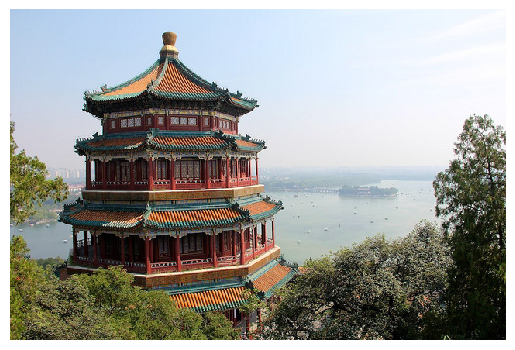

In [16]:
plot_image(china)
print(f"Tamaño imagen: {china.shape}")

Imagen con padding añadido (manualmente, para filtro 7x7):

Tamaño imagen: (433, 646, 3)


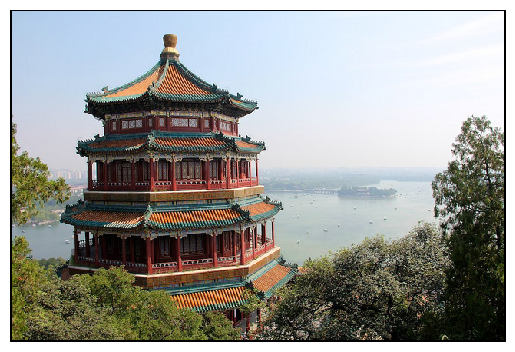

In [17]:
plot_image(manual_same_padding(images, kernel_size)[0])
print(f"Tamaño imagen: {manual_same_padding(images, kernel_size)[0].shape}")

# Capas de _pooling_

## Max _pooling_

Calculamos y mostramos el resultado de un _max pooling_ de 2x2:

In [18]:
max_pool = keras.layers.MaxPool2D(pool_size=2)

In [19]:
cropped_images = np.array([crop(image) for image in images], dtype=np.float32)
output = max_pool(cropped_images)

Saving figure china_max_pooling


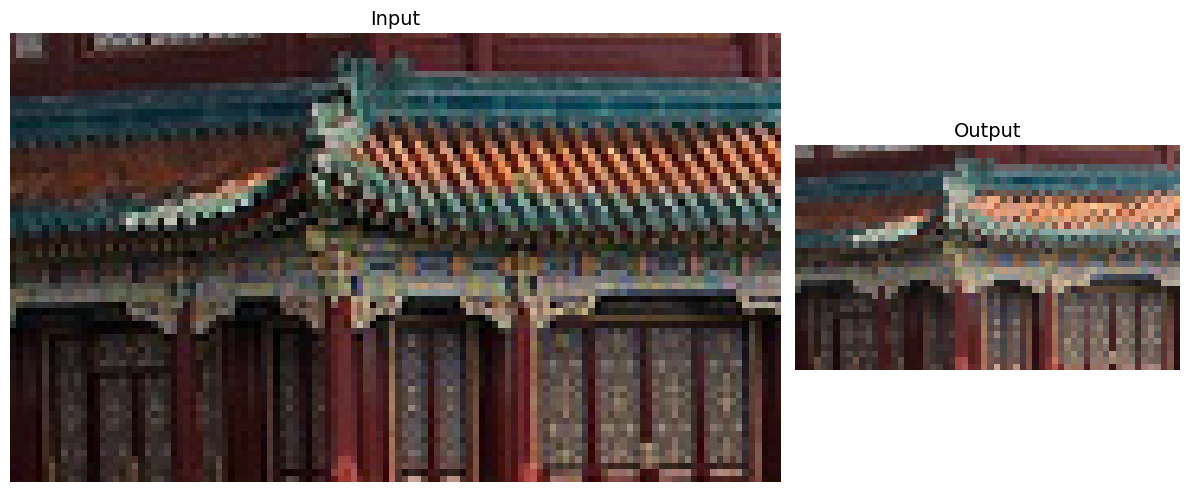

In [20]:
fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input", fontsize=14)
ax1.imshow(cropped_images[0])
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output", fontsize=14)
ax2.imshow(output[0])
ax2.axis("off")
save_fig("china_max_pooling")
plt.show()

Tamaño de las imágenes de salida:

In [21]:
print(cropped_images.shape)
print(output.shape)

(2, 70, 120, 3)
(2, 35, 60, 3)


## _Pooling_ en profundidad

Nos sirve también para ver un ejemplo de construcción de una subclase de la clase base "Layer":

In [22]:
class DepthMaxPool(keras.layers.Layer):
    def __init__(self, pool_size, strides=None, padding="VALID", **kwargs):
        super().__init__(**kwargs)
        if strides is None:
            strides = pool_size
        self.pool_size = pool_size
        self.strides = strides
        self.padding = padding
    def call(self, inputs):
        return tf.nn.max_pool(inputs,
                              ksize=(1, 1, 1, self.pool_size),
                              strides=(1, 1, 1, self.pool_size),
                              padding=self.padding)

In [23]:
depth_pool = DepthMaxPool(3)
with tf.device("/cpu:0"): # there is no GPU-kernel yet
    depth_output = depth_pool(cropped_images)
print(depth_output.shape)

(2, 70, 120, 1)


Una alternativa sería utilizar una capa `Lambda` sobre la que definimos la llamada a la función de interés (en este caso max_pool):

In [24]:
depth_pool = keras.layers.Lambda(lambda X: tf.nn.max_pool(
    X, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3), padding="VALID"))
with tf.device("/cpu:0"): # there is no GPU-kernel yet
    depth_output = depth_pool(cropped_images)
print(depth_output.shape)

(2, 70, 120, 1)


Ejemplo: máximo de los tres canales RGB:

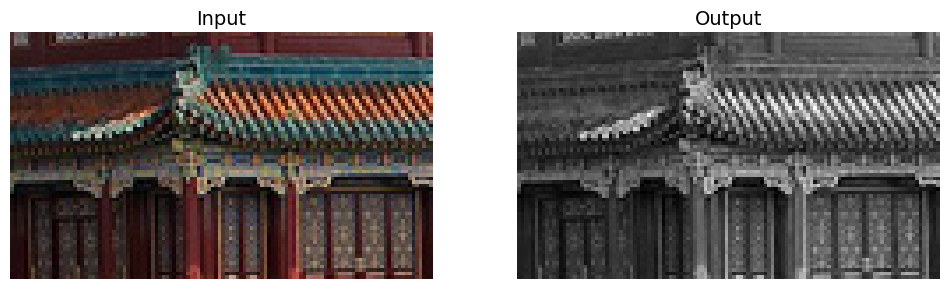

In [25]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Input", fontsize=14)
plot_color_image(cropped_images[0])  # plot the 1st image
plt.subplot(1, 2, 2)
plt.title("Output", fontsize=14)
plot_image(depth_output[0, ..., 0])  # plot the output for the 1st image
plt.axis("off")
plt.show()

## _Pooling_ de promediado

(Conocido como _average poooling_ en la literatura)

Ejemplo sobre los tres canales RGB (por separado):

In [26]:
avg_pool = keras.layers.AvgPool2D(pool_size=2)

In [27]:
output_avg = avg_pool(cropped_images)

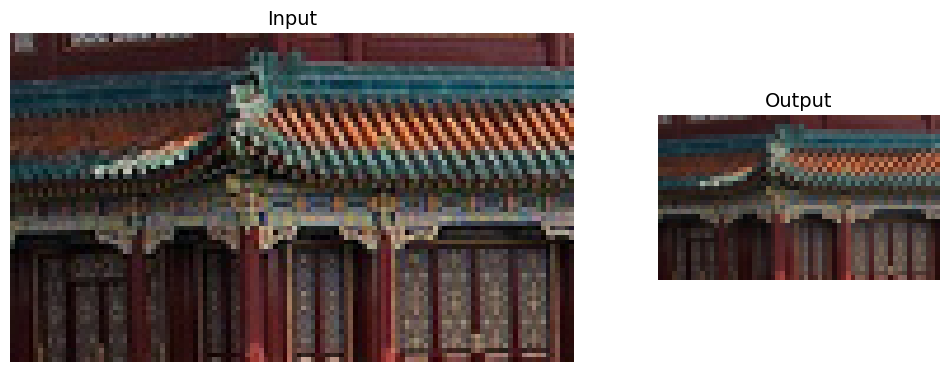

In [28]:
fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input", fontsize=14)
ax1.imshow(cropped_images[0])
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output", fontsize=14)
ax2.imshow(output_avg[0])
ax2.axis("off")
plt.show()

## _Pooling_ de promediado global

(Conocido en la literatura como _Global Average Pooling_)

Comprobación de la salida para las dos imágenes contenidas en la variable `cropped_images`: un tensor de 2x3, como corresponde a, para dos imágenes, realizar el promediado de los tres canales RGB.

Se muestra que la salida es equivalente tanto si se usa la capa Keras `GlobalAvgPool2D` como si se usa una definición propia mediante una capa `Lambda`:

In [29]:
global_avg_pool = keras.layers.GlobalAvgPool2D()
global_avg_pool(cropped_images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.2788777 , 0.22507192, 0.20967275],
       [0.51288515, 0.45952243, 0.33423486]], dtype=float32)>

In [30]:
output_global_avg2 = keras.layers.Lambda(lambda X: tf.reduce_mean(X, axis=[1, 2]))
output_global_avg2(cropped_images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.2788777 , 0.22507192, 0.20967275],
       [0.51288515, 0.45952243, 0.33423486]], dtype=float32)>

# Un ejemplo completo: _Fashion MNIST_

 Se muestra en esta sección un ejemplo concreto de un ciclo completo de entrenamiento y prueba de un modelo de clasificación de imágenes CNN sobre un _dataset_ de imágenes relativamente sencillo: el Fashion MNIST comentado en las transparencias:

In [31]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Normalización estándar & y particionamiento de los datos en subconjuntos de train / validación / test:
X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [32]:
# Define the text labels
fashion_mnist_labels = ["T-shirt/top",  # index 0
                        "Trouser",      # index 1
                        "Pullover",     # index 2
                        "Dress",        # index 3
                        "Coat",         # index 4
                        "Sandal",       # index 5
                        "Shirt",        # index 6
                        "Sneaker",      # index 7
                        "Bag",          # index 8
                        "Ankle boot"]   # index 9

Inspección de ejemplos extraidos del dataset:

X_train.shape: (55000, 28, 28, 1)


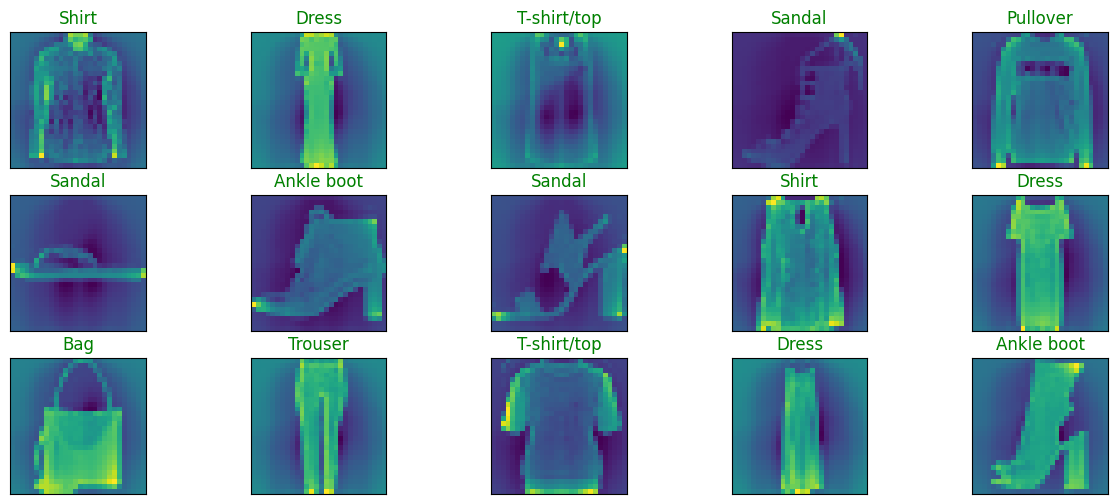

In [33]:
# Plot a random sample of 10 test images, and their ground truth labels:
figure = plt.figure(figsize=(15, 6))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    # Display each image
    ax.imshow(np.squeeze(X_test[index]))
    true_index = y_test[index]
    # Set the title for each image
    ax.set_title("{}".format(fashion_mnist_labels[true_index]), color=("green"))
print("X_train.shape:",X_train.shape)

Definición del modelo: obsérvese la inmediatez en la definición de la arquitectura, usando un simple modelo `Sequential` de Keras:

In [34]:
from functools import partial

DefaultConv2D = partial(keras.layers.Conv2D,
                        kernel_size=3, activation='relu', padding="SAME")

model = keras.models.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    keras.layers.MaxPooling2D(pool_size=2),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Una vez definido el modelo (su arquitectura), simplemente queda:
1. **"Compilarlo"**, que en realidad es simplemente añadir al grafo de computación nodos para computar la función de pérdida, la(s) métrica(s) de funcionamiento, y la lógica de control para el optimizador. Se hace con el método `.compile()`.
2. **Entrenarlo**, que es lo computacionalmente costoso: se le pasan los ejemplos etiquetados (tanto de entrenamiento como de validación, pero NO de test). Se hace con el método `.fit()`, que desencadena todo el proceso de ajuste iterativo de pesos mediante gradiente descendente.
3. **Evaluarlo**, sobre un subconjunto del dataset previamente apartado. Se hace con el método `.evaluate()`.

In [35]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.6488 - loss: 1.0022 - val_accuracy: 0.8642 - val_loss: 0.3884
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.8513 - loss: 0.4468 - val_accuracy: 0.8664 - val_loss: 0.3527
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8712 - loss: 0.3815 - val_accuracy: 0.8900 - val_loss: 0.3103
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8850 - loss: 0.3400 - val_accuracy: 0.8928 - val_loss: 0.3057
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8944 - loss: 0.3141 - val_accuracy: 0.8938 - val_loss: 0.2969
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8982 - loss: 0.3015 - val_accuracy: 0.8980 - val_loss: 0.3014
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9058 - loss: 0.2794 - val_accuracy: 0.8994 - val_loss: 0.2979
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9082 - loss

Una vez entrenado el modelo, el método `.predict()` puede usarse a partir de ese momento para predecir salidas sobre nuevas entradas. Es lo que se denomina _poner el modelo en "producción"_.

Comparamos la precisión (_accuracy_) sobre los conjuntos de entrenamiento y de test. Lógicamente, el de test suele tener una precisión algo menor casi siempre, pero si se ha mantenido separado el conjunto de test, es ya un estimador bastante decente de lo que cabe esperar del modelo:

In [36]:
train_loss, train_accuracy = model.evaluate(X_train, y_train)
train_accuracy

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9301 - loss: 0.1888


0.9294000267982483

In [37]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
test_accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8924 - loss: 0.3017


0.8934000134468079

La evolución del entrenamiento queda guardada en la variable `history` devuelta por el método `fit()`:

In [38]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

Suelen graficarse dichos valores durante el proceso de _training_, para hacerse una idea de la evolución del mismo:

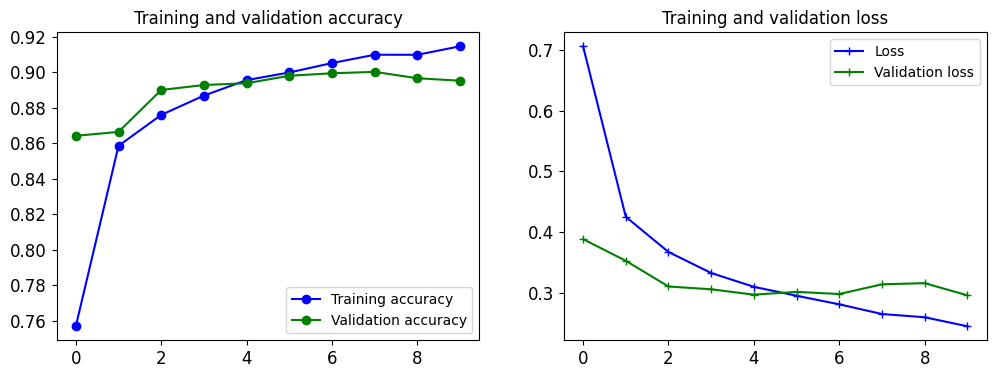

In [39]:
def plot_history(history, samples=10, init_phase_samples=None):
    epochs = history.params['epochs']

    fig, axs = plt.subplots(1,2,figsize=(12,4))

    axs[0].plot(history.history['accuracy'], 'bo-', label='Training accuracy')
    axs[0].plot(history.history['val_accuracy'], 'go-', label='Validation accuracy')
    axs[0].set_title('Training and validation accuracy')
    axs[0].legend()

    axs[1].plot(history.history['loss'], 'b+-', label='Loss')
    axs[1].plot(history.history['val_loss'], 'g+-', label='Validation loss')
    axs[1].set_title('Training and validation loss')
    axs[1].legend()

plot_history(history)

Finalmente, podemos predecir unas cuantas imágenes del conjunto de test, y comprobar los resultados:

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


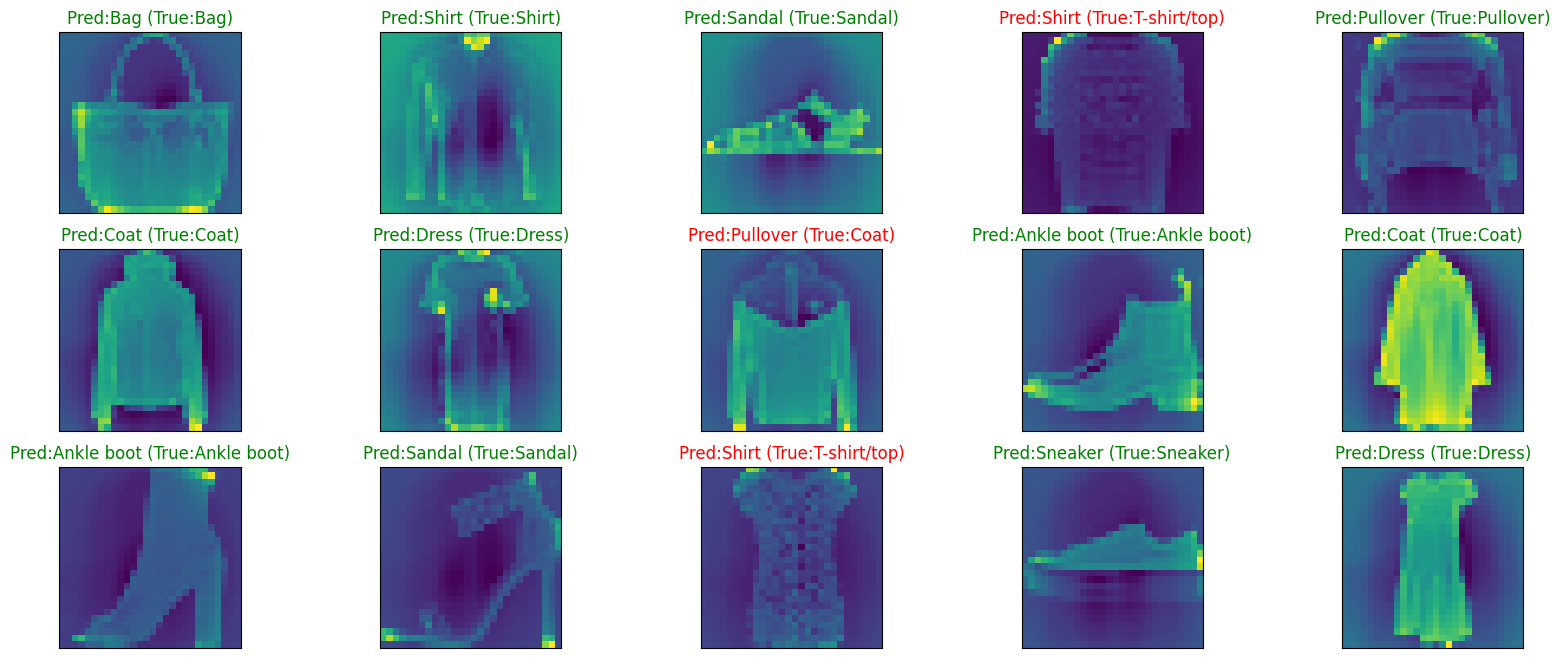

In [40]:
y_pred = model.predict(X_test)

# Dibujamos una muestra aleatoria de 10 imágenes de test, junto con la etiqueta predicha y la correcta (ground truth):
figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=15, replace=False)):
    ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[index]))
    predict_index = np.argmax(y_pred[index])
    true_index = y_test[index]
    ax.set_title("Pred:{} (True:{})".format(fashion_mnist_labels[predict_index],
                                  fashion_mnist_labels[true_index]),
                                  color=("green" if predict_index == true_index else "red"))

## Un modelo alternativo para el mismo problema: ResNet-34

Nos servirá también para ver cómo se puede diseñar una nueva capa (Keras algo más avanzado; emplea herencia de la clase base `Layer`, y redefine método `call`).

En este caso, crearemos una capa de tipo residual (como la comentada en la transparencia sobre ResNet de la teoría):

In [41]:
DefaultConv2D = partial(keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="SAME", use_bias=False)

class ResidualUnit(keras.layers.Layer):
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            keras.layers.BatchNormalization()]
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                keras.layers.BatchNormalization()]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

Una vez definida nuestra nueva capa, sólo queda utilizarla para construir nuestro modelo. Se trata de nuevo un modelo secuencial, pero algo más complejo, así que en lugar de definirlo en forma de lista de capas, usaremos el método `.add` junto con un bucle for para ir añadiendo capas, cada una con el número de filtros deseados:

In [42]:
model = keras.models.Sequential()
model.add(DefaultConv2D(64, kernel_size=7, strides=2,
                        input_shape=[224, 224, 3]))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation("relu"))
model.add(keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"))
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters
model.add(keras.layers.GlobalAvgPool2D())
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10, activation="softmax"))

Con `model.summary()` se pueden inspeccionar fácilmente las capas (y el número de parámetros) de nuestro modelo:

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 64)   │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit (ResidualUnit)    │ (None, 56, 56, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_1 (ResidualUnit)  │ (None, 56, 56, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_2 (ResidualUnit)  │ (None, 56, 56, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_3 (ResidualUnit)  │ (None, 28, 28, 128)    │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_4 (ResidualUnit)  │ (None, 28, 28, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_5 (ResidualUnit)  │ (None, 28, 28, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 28, 28, 128)    │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_7 (ResidualUnit)  │ (None, 14, 14, 256)    │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_8 (ResidualUnit)  │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_9 (ResidualUnit)  │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_10 (ResidualUnit) │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_11 (ResidualUnit) │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_12 (ResidualUnit) │ (None, 14, 14, 256)    │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_13 (ResidualUnit) │ (None, 7, 7, 512)      │     3,676,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_14 (ResidualUnit) │ (None, 7, 7, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_15 (ResidualUnit) │ (None, 7, 7, 512)      │     4,722,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,306,826 (81.28 MB)

 Trainable params: 21,289,802 (81.21 MB)

 Non-trainable params: 17,024 (66.50 KB)

#### Ejercicio ResNet-34

Un ejercicio interesante para hacerse un poco con la filosofía de Keras sería intentar replicar el entrenamiento y posterior prueba de este otro modelo con los mismos datos que en el modelo convolucional sencillo del apartado anterior.

# Uso de un modelo preentrenado

Keras incluye, _out-of-the-box_, una serie de modelos listos para ser utilizados (cuya arquitectura está ya prefijada, y cuyos pesos han sido entrenados previamente):

In [44]:
model = keras.applications.resnet50.ResNet50(weights="imagenet")

Por supuesto, para probarlos hay que ajustar las imágenes de entrada a la red al tamaño que ésta espera (224x224 en este caso). En principio, se puede hacer con _resizing_, _padding_ o _cropping_:

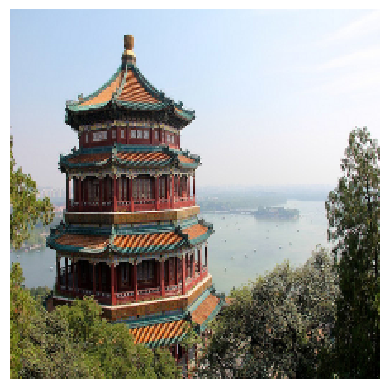

In [45]:
images_resized = tf.image.resize(images, [224, 224])
plot_color_image(images_resized[0])
plt.show()

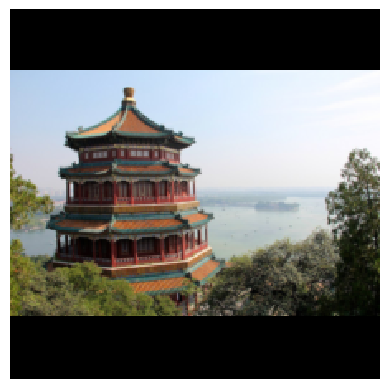

In [46]:
images_resized = tf.image.resize_with_pad(images, 224, 224, antialias=True)
plot_color_image(images_resized[0])

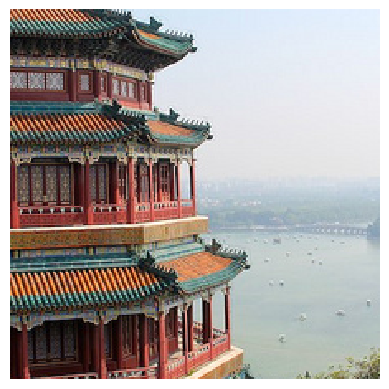

In [47]:
images_resized = tf.image.resize_with_crop_or_pad(images, 224, 224)
plot_color_image(images_resized[0])
plt.show()

Obsérvese el cambio de tamaño de las dos imágenes de prueba:

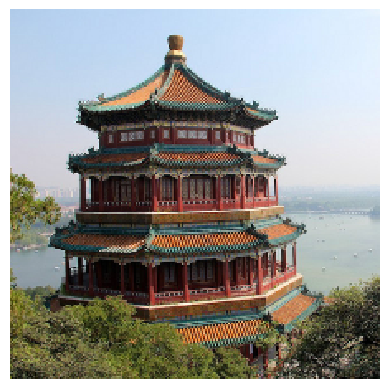

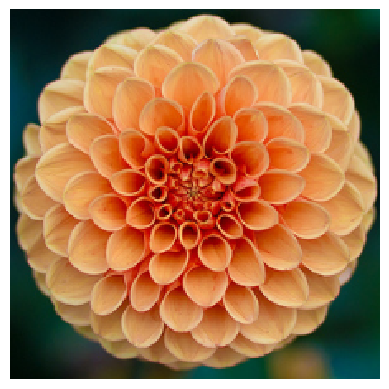

(2, 427, 640, 3)
(2, 224, 224, 3)


In [48]:
china_box = [0, 0.03, 1, 0.68]
flower_box = [0.19, 0.26, 0.86, 0.7]
images_resized = tf.image.crop_and_resize(images, [china_box, flower_box], [0, 1], [224, 224])
plot_color_image(images_resized[0])
plt.show()
plot_color_image(images_resized[1])
plt.show()
print(images.shape)
print(images_resized.shape)

Es por supuesto también muy importante alimentar a la red con los datos (rango de valores de cada píxel) normalizados tal y como ésta los espera. En este caso, ese trabajo lo hace el método `.preprocess_input()`:

In [49]:
inputs = keras.applications.resnet50.preprocess_input(images_resized * 255)
Y_proba = model.predict(inputs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


He aquí tanto las formas (`.shape`) como los tipos (`.dtype`) tanto de las entradas (_batch_ con dos imágenes de test) como del resultado de la predicción (sendos vectores de probabilidad de 1000 dimensiones, como corresponde a las 1000 clases en las que fue entrenada la red):

In [50]:
print(inputs.shape,inputs.dtype)
print(Y_proba.shape,Y_proba.dtype)

(2, 224, 224, 3) <dtype: 'float32'>
(2, 1000) float32


Es muy fácil convertir esa salida de vector de probabilidades, con tantas componentes como posibles clases, a una salida legible, con, p.e., las tres clases más probables para cada imagen de entrada:

In [51]:
top_K = keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for image_index in range(len(images)):
    print("Image #{}".format(image_index))
    for class_id, name, y_proba in top_K[image_index]:
        print("  {} - {:12s} {:.2f}%".format(class_id, name, y_proba * 100))
    print()

Image #0
  n03877845 - palace       43.39%
  n02825657 - bell_cote    43.08%
  n03781244 - monastery    11.69%

Image #1
  n04522168 - vase         53.97%
  n07930864 - cup          9.52%
  n11939491 - daisy        4.96%



El modelo en este caso es ya bastante más grande:

In [52]:
model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

Comprobamos el funcionamiento con imágenes arbitrarias descargadas de Internet

In [53]:
!wget https://upload.wikimedia.org/wikipedia/commons/7/73/Lion_waiting_in_Namibia.jpg
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/EdsboS_eojJIrdCWZRETeGUBXQ00bJUp5am2S7cZSTqMIQ?download=1 -O Lion_waiting_in_Namibia.jpg
!wget https://upload.wikimedia.org/wikipedia/commons/1/14/SwissMGB.jpg
# LINK ALTERNATIVO:
# wget https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/EWiOEtnw9WFAqtG8FCMpZ0UBaR5-0G40HPo2yMbDZSiFuw?e=Dh8oEd?download=1 -O SwissMGB.jpg

--2025-10-28 12:21:47--  https://upload.wikimedia.org/wikipedia/commons/7/73/Lion_waiting_in_Namibia.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 314509 (307K) [image/jpeg]
Saving to: ‘Lion_waiting_in_Namibia.jpg.1’

Lion_waiting_in_Nam 100%[===================>] 307.14K  --.-KB/s    in 0.07s   

2025-10-28 12:21:47 (4.59 MB/s) - ‘Lion_waiting_in_Namibia.jpg.1’ saved [314509/314509]

--2025-10-28 12:21:47--  https://upload.wikimedia.org/wikipedia/commons/1/14/SwissMGB.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 198.35.26.112, 2620:0:863:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|198.35.26.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 241482 (236K) [image/jpeg]
Saving to: ‘SwissMGB.jpg.1’

SwissMGB.jpg.1      100%[=====

In [54]:
imgs_new = []
for filname in ["./Lion_waiting_in_Namibia.jpg","./SwissMGB.jpg"]:
  img_new = cv2.imread(filname)
  img_new = cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB)
  img_new_resized = tf.image.resize(img_new, [224, 224])
  imgs_new.append(img_new_resized)
imgs_new = np.array(imgs_new)

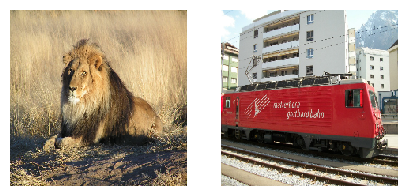

In [55]:
fig, axs = plt.subplots(1,len(imgs_new), figsize=(5,5*len(imgs_new)))
for i,ax in enumerate(axs):
  ax.imshow(imgs_new[i]/255, interpolation="nearest")
  ax.axis("off")

In [56]:
inputs = keras.applications.resnet50.preprocess_input(imgs_new)
Y_proba = model.predict(inputs)
top_K = keras.applications.resnet50.decode_predictions(Y_proba, top=3)
for i in range(len(imgs_new)):
  print(f"Results for image {i}:")
  for class_id, name, y_proba in top_K[i]:
    print("  {} - {:12s} {:.2f}%".format(class_id, name, y_proba * 100))
  print("\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Results for image 0:
  n02129165 - lion         100.00%
  n02106030 - collie       0.00%
  n02130308 - cheetah      0.00%


Results for image 1:
  n03895866 - passenger_car 42.11%
  n03393912 - freight_car  27.72%
  n03272562 - electric_locomotive 26.36%




# _Transfer Learning_

Finalmente, mostramos aquí un ejemplo de _transfer learning_: emplear el _backbone_ de una CNN preentrenada para, añadiendo unas pocas capas adicionales, reentrenar con un _dataset_ completamente nuevo:

In [57]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)

In [58]:
info.splits["train"]

<SplitInfo num_examples=3670, num_shards=2>

In [59]:
class_names = info.features["label"].names
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [60]:
n_classes = info.features["label"].num_classes
print(n_classes)

5


In [61]:
dataset_size = info.splits["train"].num_examples
dataset_size

3670

In [62]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

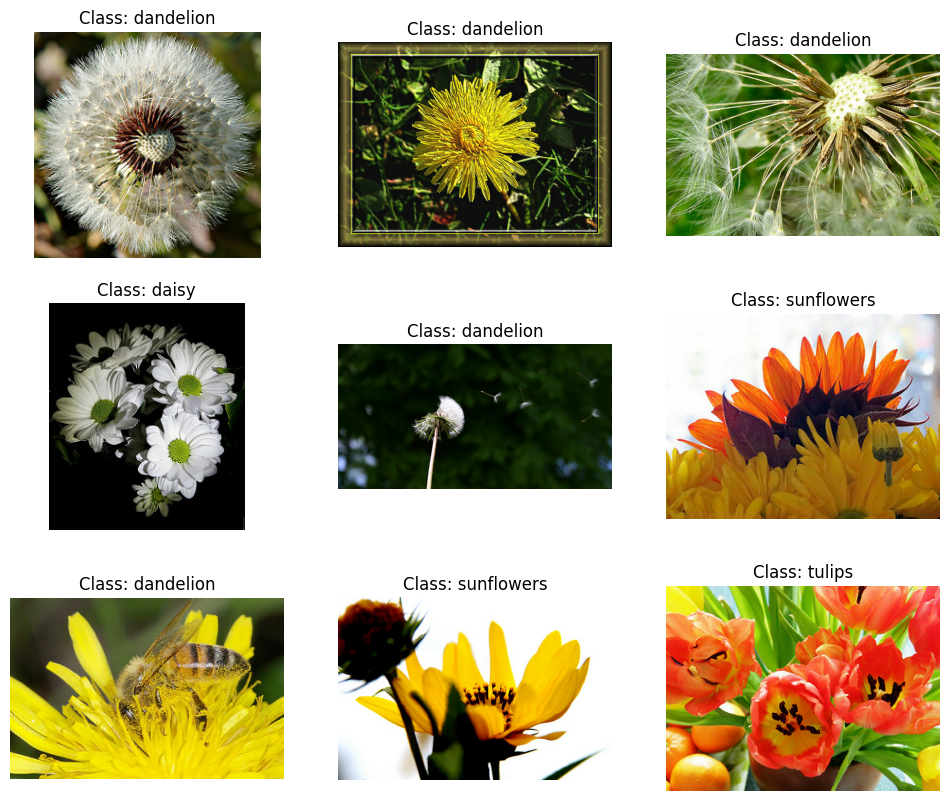

In [63]:
plt.figure(figsize=(12, 10))
index = 0
for image, label in train_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title("Class: {}".format(class_names[label]))
    plt.axis("off")

plt.show()

Preprocesamiento básico:

In [64]:
def preprocess(image, label):
    resized_image = tf.image.resize(image, [224, 224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

Sencillo ejemplo de _data augmentation_:
---



El _data augmentation_ consiste en hacer pequeños cambios sobre las imágenes de entrada para multiplicar el número de ejemplos a usar en el entrenamiento (dado que obtener los (muchos) ejemplos etiquetados necesarios para entrenar una CNN es un proceso manual y, por tanto, bastante costoso).

En este ejemplo, hacemos recortes aleatorios de las imágenes de entrada, y las _flipamos_ de izquierda a derecha, como esquema básico para realizar dicho _data augmentation_:

In [65]:
def central_crop(image):
    shape = tf.shape(image)
    min_dim = tf.reduce_min([shape[0], shape[1]])
    top_crop = (shape[0] - min_dim) // 4
    bottom_crop = shape[0] - top_crop
    left_crop = (shape[1] - min_dim) // 4
    right_crop = shape[1] - left_crop
    return image[top_crop:bottom_crop, left_crop:right_crop]

def random_crop(image):
    shape = tf.shape(image)
    min_dim = tf.reduce_min([shape[0], shape[1]]) * 90 // 100
    return tf.image.random_crop(image, [min_dim, min_dim, 3])

def preprocess(image, label, randomize=False):
    if randomize:
        cropped_image = random_crop(image)
        cropped_image = tf.image.random_flip_left_right(cropped_image)
    else:
        cropped_image = central_crop(image)
    resized_image = tf.image.resize(cropped_image, [224, 224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

batch_size = 32
train_set = train_set_raw.shuffle(1000).repeat()
train_set = train_set.map(partial(preprocess, randomize=True)).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

Mostramos algunos ejemplos de los resultados de aplicar dicho esquema de _data augmentation_ a las imágenes originales:

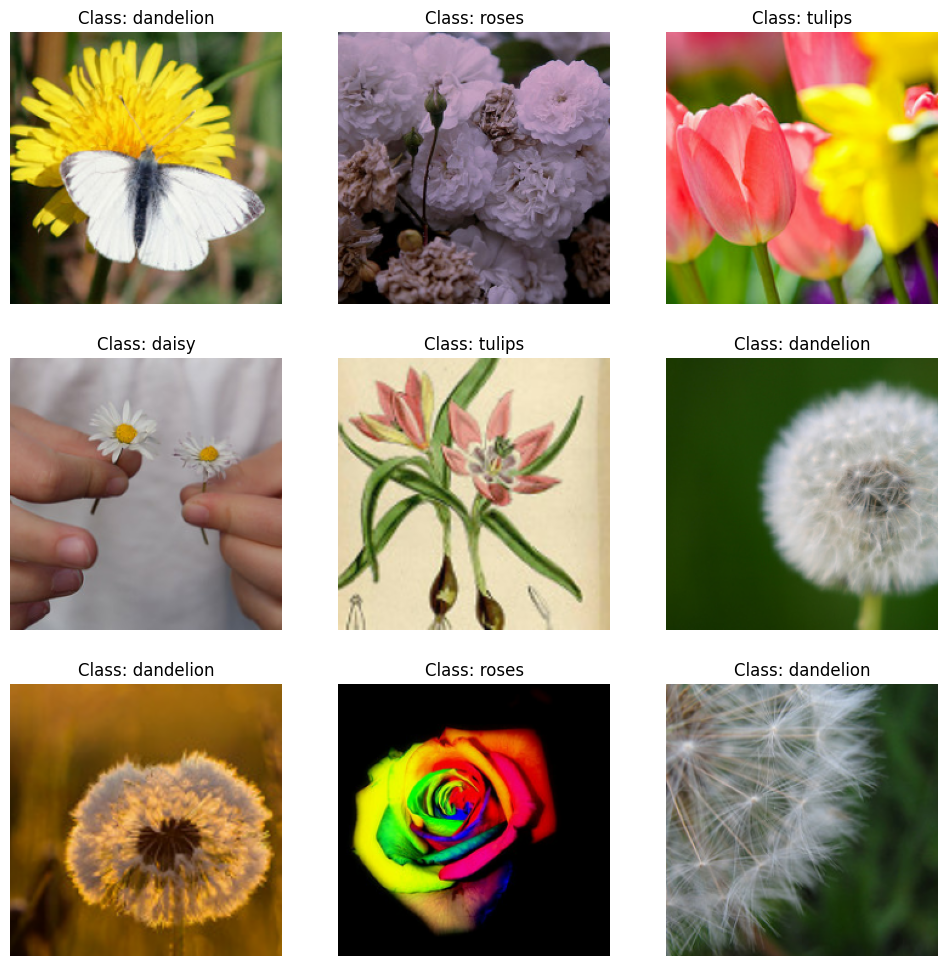

In [66]:
plt.figure(figsize=(12, 12))
for X_batch, y_batch in train_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow(X_batch[index] / 2 + 0.5)
        plt.title("Class: {}".format(class_names[y_batch[index]]))
        plt.axis("off")

plt.show()

Usaremos **Xception** como CNN _backbone_. Es una red con más de 100 capas, cuyos pesos "congelaremos", y a la que simplemente añadiremos una capa `GlobalAveragePooling2D` seguida de una densa (`Dense`) con activación `softmax`:

In [67]:
base_model = keras.applications.xception.Xception(weights="imagenet",
                                                  include_top=False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
model = keras.models.Model(inputs=base_model.input, outputs=output)

In [68]:
for index, layer in enumerate(base_model.layers):
    print(index, layer.name)

0 input_layer_3
1 block1_conv1
2 block1_conv1_bn
3 block1_conv1_act
4 block1_conv2
5 block1_conv2_bn
6 block1_conv2_act
7 block2_sepconv1
8 block2_sepconv1_bn
9 block2_sepconv2_act
10 block2_sepconv2
11 block2_sepconv2_bn
12 conv2d_44
13 block2_pool
14 batch_normalization_36
15 add
16 block3_sepconv1_act
17 block3_sepconv1
18 block3_sepconv1_bn
19 block3_sepconv2_act
20 block3_sepconv2
21 block3_sepconv2_bn
22 conv2d_45
23 block3_pool
24 batch_normalization_37
25 add_1
26 block4_sepconv1_act
27 block4_sepconv1
28 block4_sepconv1_bn
29 block4_sepconv2_act
30 block4_sepconv2
31 block4_sepconv2_bn
32 conv2d_46
33 block4_pool
34 batch_normalization_38
35 add_2
36 block5_sepconv1_act
37 block5_sepconv1
38 block5_sepconv1_bn
39 block5_sepconv2_act
40 block5_sepconv2
41 block5_sepconv2_bn
42 block5_sepconv3_act
43 block5_sepconv3
44 block5_sepconv3_bn
45 add_3
46 block6_sepconv1_act
47 block6_sepconv1
48 block6_sepconv1_bn
49 block6_sepconv2_act
50 block6_sepconv2
51 block6_sepconv2_bn
52 blo

Al estar `congelados` la mayoría de los pesos, el entrenamiento puede ser (relativamente) mucho más rápido (por ahora sólo involucra a la capa superior):

In [69]:
for layer in base_model.layers:
    layer.trainable = False

optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set,
                    steps_per_epoch=int(0.75 * dataset_size / batch_size),
                    validation_data=valid_set,
                    validation_steps=int(0.15 * dataset_size / batch_size),
                    epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 39s 207ms/step - accuracy: 0.6787 - loss: 1.8661 - val_accuracy: 0.8070 - val_loss: 1.2525
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.8819 - loss: 0.7993 - val_accuracy: 0.8621 - val_loss: 0.9208
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - accuracy: 0.8947 - loss: 0.7568 - val_accuracy: 0.8529 - val_loss: 1.4395
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.9243 - loss: 0.4257 - val_accuracy: 0.8254 - val_loss: 1.2899
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - accuracy: 0.9247 - loss: 0.4368 - val_accuracy: 0.8419 - val_loss: 1.5214


Pero, para obtener los mejores resultados, conviene también tras ello "descongelar" los pesos del _backbone_, y hacer un ajuste fino de, ya sí, todos los pesos de la red (ojo; esta celda puede tardar ya más de una hora en ejecutarse; por eso está deshabilitada por defecto):

In [70]:
if False:
  for layer in base_model.layers:
      layer.trainable = True

  optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
  model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
                metrics=["accuracy"])
  history = model.fit(train_set,
                      steps_per_epoch=int(0.75 * dataset_size / batch_size),
                      validation_data=valid_set,
                      validation_steps=int(0.15 * dataset_size / batch_size),
                      epochs=40)

## Ejercicio transfer learning

Terminar de entrenar esta red, evaluar los resultados sobre el test, y mostrar gráficamente tanto el historial (evolución de _loss_ y _accuracy_) del aprendizaje como los resultados de la clasificación sobre algunos ejemplos de test (al estilo de cómo se hizo con Fashion MNIST).

# CNN para MNIST

Un ejemplo final, con el (muy) conocido _dataset_ MNIST. El siguiente modelo usa dos capas convolucionales, seguidas de una de _pooling_, un _dropout_ del 25% para añadir algo de regularización, a continuación una capa densa seguida de otro dropout (ahora del 50%), y finalmente la capa de salida. Alcanza un 99.2% de precisión en el conjunto de test:

In [71]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train_full = X_train_full / 255.
X_test = X_test / 255.
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [72]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = keras.models.Sequential([
    keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
print("Loss y accuracy sobre conjunto de test:")
model.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.8799 - loss: 0.3790 - val_accuracy: 0.9870 - val_loss: 0.0493
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9747 - loss: 0.0868 - val_accuracy: 0.9878 - val_loss: 0.0378
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9816 - loss: 0.0622 - val_accuracy: 0.9892 - val_loss: 0.0362
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9855 - loss: 0.0496 - val_accuracy: 0.9902 - val_loss: 0.0398
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9880 - loss: 0.0404 - val_accuracy: 0.9916 - val_loss: 0.0311
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9886 - loss: 0.0363 - val_accuracy: 0.9924 - val_loss: 0.0276
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9896 - loss: 0.0316 - val_accuracy: 0.9934 - val_loss: 0.0300
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9907 - loss: 0.0293 -

[0.030828561633825302, 0.9915000200271606]

#### Ejercicio MNIST

Evaluar y mostrar gráficamente los resultados obtenidos para ésta última red entrenada con los dígitos MNIST (al ser más sencilla, se entrena más rápido, y obtiene resultados superiores al 99% de precisión).

#Otras CNNs más allá de la clasificación

Un último ejercicio final adicional interesante: seguir el tutorial de _Style transfer_ de la web de TensorFlow [Style Transfer tutorial](https://homl.info/styletuto). Es una forma divertida de crear arte usando _Deep Learning_. Simplemente hay que abrir el _notebook_ de Colab y seguir sus instrucciones.


Existen literalmente centenares de notebooks de Google Colab con ejemplos (con código y datos completamente abiertos) de aplicaciones de CNNs disponibles en Internet, de complejidades muy variables. Es un tema de investigación completamente en ebullición en el momento actual.

In [73]:
!date

Tue Oct 28 12:24:49 PM UTC 2025
